<a id="top"></a>
# San Francisco Reported-Incident Intelligence
### Reproducible analysis and citywide time-series forecasting, 2018–2026

**Sileshi T. Hirpa**  
Data Science · Business Analytics · Mathematical Foundations  
San Francisco Bay Area · Updated August 2026

[Repository](https://github.com/sileshith/sf-incident-forecasting) · [Live dashboard](https://sf-incident-forecasting.streamlit.app/) · [Data source](https://data.sfgov.org/d/wg3w-h783)

> This project analyzes reported and recorded SFPD incidents. It does not measure all crime, establish neighborhood safety, estimate individual risk, or recommend patrol allocation.


## Executive summary

This publication notebook reads the same versioned artifacts used by the deployed application.

- **942,427** canonical records across 2018–2025
- Deterministic ingestion, schema validation, continuity checks, artifact hashes, and CI
- Six expanding-window forecast origins with fixed three-month horizons
- Seasonal naive, additive ETS, and SARIMA evaluated on identical folds
- **SARIMA selected by mean MASE:** 0.80; mean MAPE: 5.78%; MAE: 432
- Six-month 2026 citywide outlook with 95% model prediction intervals

The forecast is an aggregate statistical estimate—not a causal model or guaranteed future outcome.


## CRISP-DM implementation

| Phase | Implementation |
|---|---|
| Business understanding | Aggregate, non-causal planning question and prespecified success criteria |
| Data understanding | Source grain, coverage, continuity, concentration, and reporting limitations |
| Data preparation | Normalized schema, separate analytical aggregates, metadata, and hashes |
| Modeling | Transparent seasonal benchmark, ETS, and SARIMA |
| Evaluation | Repeated rolling-origin backtests; selection by MASE |
| Deployment | Versioned artifacts, model card, Streamlit, downloads, and monitoring |

## Contents
1. [Business understanding](#business)
2. [Data understanding](#understanding)
3. [Data preparation](#preparation)
4. [Modeling](#modeling)
5. [Evaluation and outlook](#evaluation)
6. [Deployment and monitoring](#deployment)
7. [Limitations](#limitations)
8. [Reproducibility](#reproducibility)


<a id="business"></a>
## 1. Business understanding

### Objective
Describe recorded SFPD incident patterns and produce a transparent short-horizon citywide volume forecast without inferring personal safety or causality.

### Questions
- How did monthly recorded volume change from 2018 through 2025?
- Where are records concentrated, and what temporal rhythms appear?
- Which candidate model performs best across repeated historical origins?
- What range of aggregate recorded volume is plausible over six months in 2026?

### Success criteria
The selected model must outperform seasonal naive on mean MASE across multiple origins, report absolute and percentage errors, preserve uncertainty, and be reproducible from documented artifacts.


<a id="understanding"></a>
## 2. Data understanding

The source is DataSF dataset **wg3w-h783**. A row is an incident record, not necessarily a unique criminal event; a report may be associated with more than one incident code. Records may be revised or removed.

Therefore, rows, reports, and unique events are not interchangeable. Recorded counts reflect reporting, enforcement, classification, and source-system practices. Neighborhood totals are not exposure-adjusted safety rates.


In [1]:
from pathlib import Path
import hashlib, json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns",20)

def find_root(start):
    for p in (start.resolve(),*start.resolve().parents):
        if (p/"data"/"processed"/"metadata.json").exists(): return p
    raise FileNotFoundError("Production artifacts not found")

ROOT=find_root(Path.cwd()); P=ROOT/"data"/"processed"
metadata=json.loads((P/"metadata.json").read_text())
monthly=pd.read_parquet(P/"monthly_citywide.parquet")
nc=pd.read_parquet(P/"monthly_neighborhood_category.parquet")
hw=pd.read_parquet(P/"hourly_weekday_counts.parquet")
backtest=pd.read_csv(P/"backtest_summary.csv")
preds=pd.read_parquet(P/"backtest_predictions.parquet")
forecast=pd.read_parquet(P/"forecast_citywide_monthly_2026.parquet")
print("Project root:",ROOT)
print("Generated:",metadata["generated_at_utc"])
print(f'Canonical records: {metadata["source_rows"]:,}')
print("Window:",metadata["study_window"])


Project root: /Users/sileshihirpa/Desktop/ASU/projects/san-francisco-crime-forecasting
Generated: 2026-08-14T22:51:01.452716+00:00
Canonical records: 942,427
Window: ['2018-01-01', '2025-12-31']


In [2]:
inventory=pd.DataFrame([
("monthly_citywide",*monthly.shape),
("monthly_neighborhood_category",*nc.shape),
("hourly_weekday_counts",*hw.shape),
("backtest_predictions",*preds.shape),
("forecast_2026",*forecast.shape)],columns=["artifact","rows","columns"])
display(inventory)


,artifact,rows,columns
0,monthly_citywide,96,2
1,monthly_neighborhood_category,86506,5
2,hourly_weekday_counts,6957,4
3,backtest_predictions,54,11
4,forecast_2026,6,5


In [3]:
monthly=monthly.copy()
monthly["date"]=pd.to_datetime(monthly["month"])
expected=pd.date_range("2018-01-01","2025-12-01",freq="MS")
checks=pd.Series({
"monthly rows":len(monthly),"expected rows":len(expected),
"duplicate months":monthly.date.duplicated().sum(),
"missing months":len(expected.difference(monthly.date)),
"null totals":monthly.incidents.isna().sum(),
"negative totals":(monthly.incidents<0).sum()},name="result")
display(checks.to_frame())
assert checks[["duplicate months","missing months","null totals","negative totals"]].sum()==0


,result
monthly rows,96
expected rows,96
duplicate months,0
missing months,0
null totals,0
negative totals,0


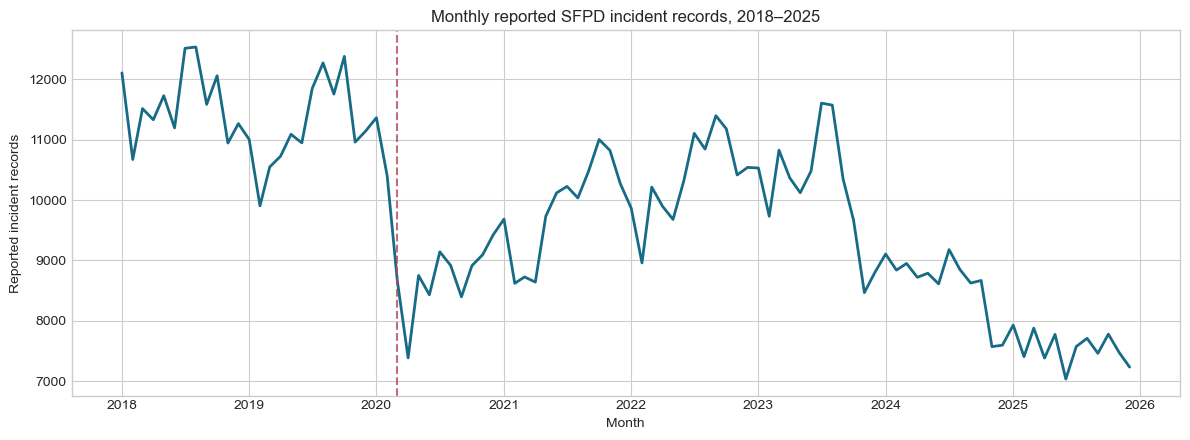

In [4]:
fig,ax=plt.subplots(figsize=(12,4.5))
ax.plot(monthly.date,monthly.incidents,color="#176B87",lw=2)
ax.axvline(pd.Timestamp("2020-03-01"),color="#B04A5A",ls="--",alpha=.8)
ax.set(title="Monthly reported SFPD incident records, 2018–2025",xlabel="Month",ylabel="Reported incident records")
plt.tight_layout(); plt.show()


The series contains a material disruption beginning in 2020 and does not simply return to its pre-2020 level. This is an observed change in recorded volume—not evidence of a single cause.


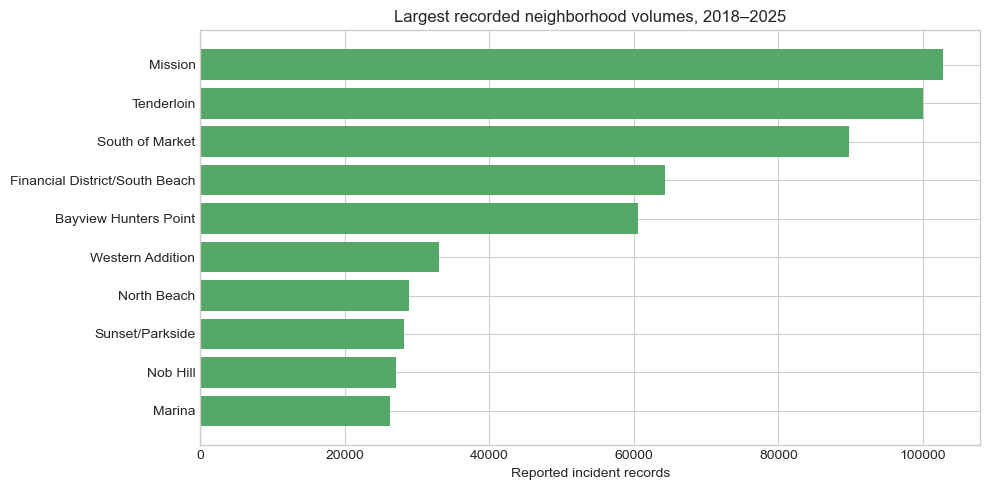

,neighborhood,incidents
0,Mission,102766
1,Tenderloin,100050
2,South of Market,89820
3,Financial District/South Beach,64361
4,Bayview Hunters Point,60515
5,Western Addition,32976
6,North Beach,28913
7,Sunset/Parkside,28140
8,Nob Hill,27095
9,Marina,26275


In [5]:
totals=(nc.groupby("neighborhood",as_index=False).incidents.sum().sort_values("incidents",ascending=False))
top=totals.head(10).sort_values("incidents")
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(top.neighborhood,top.incidents,color="#55A868")
ax.set(title="Largest recorded neighborhood volumes, 2018–2025",xlabel="Reported incident records",ylabel="")
plt.tight_layout(); plt.show()
display(totals.head(10).reset_index(drop=True))


Neighborhood concentration may reflect exposure, commercial activity, land use, transit, reporting behavior, and enforcement intensity. It is not a neighborhood safety ranking.


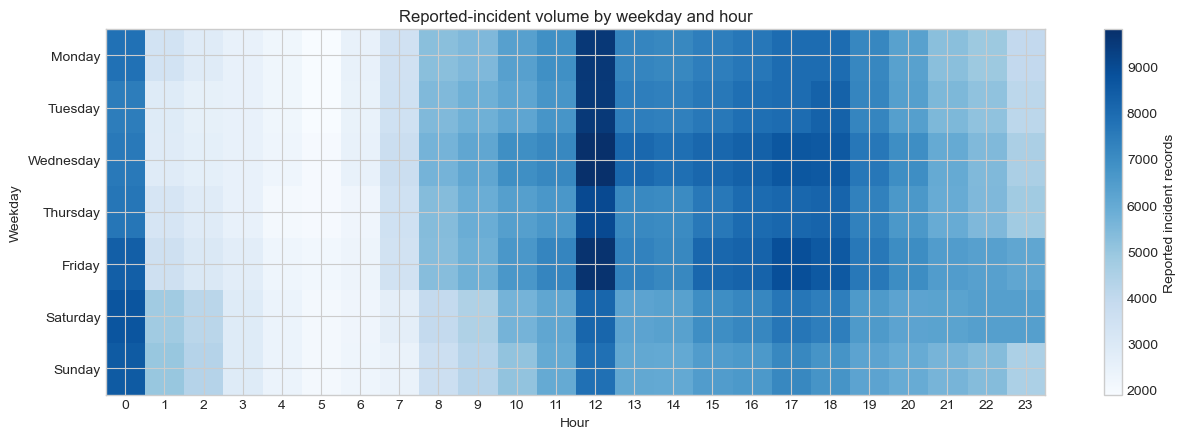

In [6]:
order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
matrix=hw.pivot_table(index="weekday_label",columns="hour",values="incidents",aggfunc="sum",fill_value=0).reindex(order)
fig,ax=plt.subplots(figsize=(13,4.5))
im=ax.imshow(matrix,aspect="auto",cmap="Blues")
ax.set(title="Reported-incident volume by weekday and hour",xlabel="Hour",ylabel="Weekday")
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_yticks(range(7)); ax.set_yticklabels(order)
fig.colorbar(im,ax=ax,label="Reported incident records")
plt.tight_layout(); plt.show()


<a id="preparation"></a>
## 3. Data preparation

The tested pipeline:
1. Retrieves the complete study window with deterministic pagination.
2. Normalizes source fields and canonical timestamps.
3. Validates the study window and monthly continuity.
4. Preserves citywide records independently of missing spatial fields.
5. Materializes monthly, neighborhood/category, and hour/weekday artifacts.
6. Records generation metadata and SHA-256 hashes.

Separating citywide forecasting from spatial subsets prevents coordinate or neighborhood missingness from biasing the citywide target.


In [7]:
def sha(path):
    h=hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()
verified=[]
for name,info in metadata["files"].items():
    verified.append({"artifact":name,"rows":info["rows"],"hash_verified":sha(P/name)==info["sha256"]})
verified=pd.DataFrame(verified)
display(verified)
assert verified.hash_verified.all()


,artifact,rows,hash_verified
0,monthly_citywide.parquet,96,True
1,monthly_neighborhood_category.parquet,86506,True
2,hourly_weekday_counts.parquet,6957,True


<a id="modeling"></a>
## 4. Modeling

**Target:** monthly citywide count of recorded SFPD incident records.

**Candidates**
- Seasonal naive: same calendar month one year earlier
- Additive Holt-Winters ETS
- SARIMA(1,1,1)(1,1,1,12)

**Evaluation design**
- Expanding-window rolling-origin backtest
- Six origins; fixed three-month horizon
- Primary metric: MASE
- Supporting metrics: MAE, RMSE, MAPE, and WAPE
- Final refit on all 2018–2025 months only after model selection

Transparent models are appropriate for a 96-observation monthly series; exploratory complexity is not promoted without consistent out-of-sample benefit.


,model,mae,rmse,mape,wape,mase
0,sarima,432,482,5.78%,5.76%,0.80
1,ets,434,490,5.81%,5.78%,0.81
2,seasonal_naive,"1,062","1,113",14.14%,14.12%,1.97


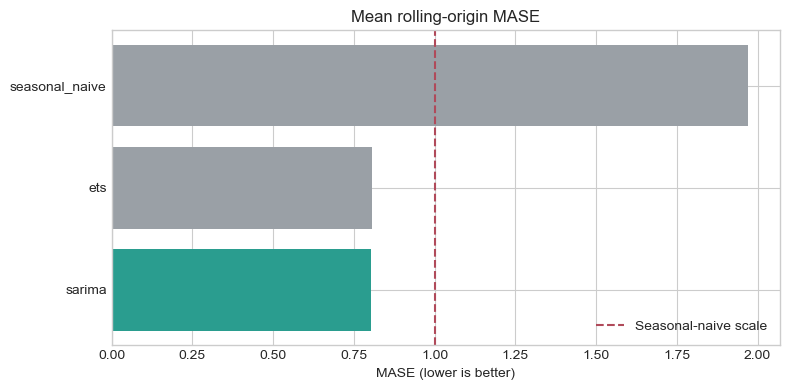

In [8]:
results=backtest[["model","mae","rmse","mape","wape","mase"]].sort_values("mase").reset_index(drop=True)
display(results.style.format({"mae":"{:,.0f}","rmse":"{:,.0f}","mape":"{:.2f}%","wape":"{:.2f}%","mase":"{:.2f}"}))
fig,ax=plt.subplots(figsize=(8,4))
r=results.sort_values("mase")
ax.barh(r.model,r.mase,color=["#2A9D8F" if x=="sarima" else "#9AA0A6" for x in r.model])
ax.axvline(1,color="#B04A5A",ls="--",label="Seasonal-naive scale")
ax.set(title="Mean rolling-origin MASE",xlabel="MASE (lower is better)",ylabel="")
ax.legend(); plt.tight_layout(); plt.show()


SARIMA produced the lowest mean MASE (0.80), narrowly ahead of ETS (0.81) and materially ahead of seasonal naive (1.97). The SARIMA–ETS difference is modest; SARIMA is selected because it minimizes the prespecified primary metric.


<a id="evaluation"></a>
## 5. Evaluation and 2026 outlook

Repeated origins reduce dependence on one favorable holdout. They do not guarantee future accuracy; folds are historical and future structural changes may differ.


In [9]:
errors=(preds.assign(abs_error=lambda x:(x.actual-x.forecast).abs())
.groupby(["model","horizon"],as_index=False).agg(mae=("abs_error","mean"),n=("abs_error","size")))
display(errors.pivot(index="model",columns="horizon",values="mae").style.format("{:,.0f}"))


horizon,1,2,3
model,,,
ets,246,499,556
sarima,232,501,563
seasonal_naive,"1,232","1,079",877


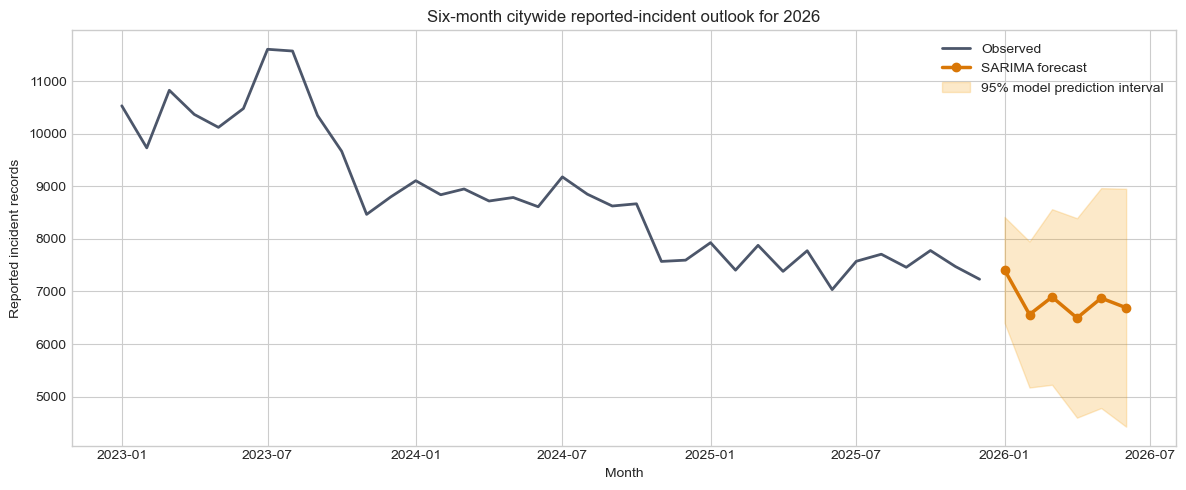

Mean monthly point forecast: 6,822


In [10]:
forecast=forecast.copy(); forecast["month"]=pd.to_datetime(forecast.month)
history=monthly.tail(36)
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(history.date,history.incidents,color="#4C566A",lw=2,label="Observed")
ax.plot(forecast.month,forecast.forecast,color="#D97706",lw=2.5,marker="o",label="SARIMA forecast")
ax.fill_between(forecast.month,forecast.lower,forecast.upper,color="#F59E0B",alpha=.22,label="95% model prediction interval")
ax.set(title="Six-month citywide reported-incident outlook for 2026",xlabel="Month",ylabel="Reported incident records")
ax.legend(); plt.tight_layout(); plt.show()
print(f'Mean monthly point forecast: {forecast.forecast.mean():,.0f}')


The point forecast centers on approximately 6,822 records per month. Intervals are conditional on the fitted model and do not include every possible policy, reporting-system, event, economic, or behavioral shock.


<a id="deployment"></a>
## 6. Deployment and monitoring

**Architecture:** DataSF API → deterministic ingestion → schema validation → versioned artifacts and hashes → rolling-origin evaluation and model card → Streamlit dashboard.

The dashboard reads lightweight validated artifacts rather than downloading or retraining on nearly one million records at startup.

When a complete month arrives: rebuild artifacts, inspect revisions, rerun all folds, compare against seasonal naive, track error by horizon, review interval calibration, and promote a new model only through the same evaluation gate.


<a id="limitations"></a>
## 7. Limitations and responsible use

- Records do not represent all crime or unique events.
- Reporting, enforcement, classification, approval, and revision affect counts.
- Neighborhood totals are not adjusted for population, visitors, or foot traffic.
- The pandemic is a major structural break.
- Forecasts exclude weather, events, policy, economic conditions, and reporting delays.
- Citywide forecasts do not describe neighborhood-level or individual risk.
- Prediction intervals are conditional and require monitoring.
- Results are descriptive and predictive, not causal.

This work must not be used as a personal-safety score, neighborhood ranking, causal claim, or patrol-allocation system.


<a id="reproducibility"></a>
## 8. Reproducibility and references

### Commands

~~~bash
git clone https://github.com/sileshith/sf-incident-forecasting.git
cd sf-incident-forecasting
uv sync --extra dev
uv run sf-incidents-build
uv run sf-incidents-evaluate
uv run ruff check .
uv run pytest
uv run streamlit run app.py
~~~

### References
- DataSF, *Police Department Incident Reports: 2018 to Present*, wg3w-h783
- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*
- [Production model card](https://github.com/sileshith/sf-incident-forecasting/blob/main/docs/model_card.md)
- [Repository](https://github.com/sileshith/sf-incident-forecasting)
- [Live dashboard](https://sf-incident-forecasting.streamlit.app/)

[Back to top](#top)
